# E030 — Image TTA: rotation averaging at inference

E028 revealed the eigenface subspace collapses under rotation (±15° → 7.31% EER).
This notebook tests **test-time augmentation (TTA)**: score each image at
−20°, −10°, 0°, +10°, +20°, average the 5 log-odds. No retraining.
Compare against E028 baseline on both clean val and the full stress suite.

In [1]:
from pathlib import Path
import sys, io
sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from scipy.ndimage import gaussian_filter, rotate as ndimage_rotate
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

DATA = Path('../data').resolve()
SEED = 67
TTA_ANGLES = [-20, -10, 0, 10, 20]

manifest = load_manifest(DATA)
print(f'{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target')

222 samples — 30 target, 192 non-target


In [2]:
def find_png(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.png')
        if p.exists():
            return p
    raise FileNotFoundError(stem)

def load_image(png_path):
    img = np.array(PILImage.open(png_path).convert('RGB'), dtype=np.float32)
    return img.mean(axis=2).flatten()

def load_images(df, data_dir):
    return np.stack([load_image(find_png(r['stem'], data_dir)) for _, r in df.iterrows()])

# E007 augmentation
def aug_flip(x):
    return x.reshape(80, 80)[:, ::-1].flatten()
def aug_brightness(x, rng):
    return np.clip(x * rng.uniform(0.7, 1.3), 0, 255)
def aug_noise(x, rng, sigma=15.0):
    return np.clip(x + rng.normal(0, sigma, x.shape), 0, 255)

def augment_all(X, y, seed):
    rng = np.random.default_rng(seed)
    aug_X, aug_y = [], []
    for xi, yi in zip(X, y):
        aug_X.append(aug_flip(xi));             aug_y.append(yi)
        aug_X.append(aug_brightness(xi, rng));  aug_y.append(yi)
        aug_X.append(aug_noise(xi, rng));       aug_y.append(yi)
    return np.vstack([X, np.stack(aug_X)]), np.concatenate([y, np.array(aug_y)])

print('IO + E007 aug defined.')

IO + E007 aug defined.


In [3]:
# Stress functions (identical to E028)
def stress_jpeg(x, quality=15):
    img = PILImage.fromarray(x.reshape(80, 80).astype(np.uint8), mode='L')
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return np.array(PILImage.open(buf).convert('L'), dtype=np.float32).flatten()

def stress_blur(x, sigma=3.0):
    return gaussian_filter(x.reshape(80, 80), sigma=sigma).flatten()

def stress_rotate(x, angle, rng):
    a = rng.uniform(-angle, angle)
    r = ndimage_rotate(x.reshape(80, 80), a, reshape=False, mode='reflect')
    return np.clip(r, 0, 255).flatten()

def stress_occlude(x, patch=20, rng=None):
    img = x.reshape(80, 80).copy()
    y0 = rng.integers(0, 80 - patch)
    x0 = rng.integers(0, 80 - patch)
    img[y0:y0+patch, x0:x0+patch] = 0
    return img.flatten()

def stress_downsample(x):
    img = PILImage.fromarray(x.reshape(80, 80).astype(np.uint8), mode='L')
    down = img.resize((40, 40), PILImage.BILINEAR)
    up   = down.resize((80, 80), PILImage.BILINEAR)
    return np.array(up, dtype=np.float32).flatten()

def stress_all(x, rng):
    x = stress_jpeg(x, quality=15)
    x = stress_blur(x, sigma=3.0)
    x = stress_rotate(x, 15, rng)
    x = stress_occlude(x, 20, rng=rng)
    x = stress_downsample(x)
    return x

def apply_stress(X, kind, seed):
    rng = np.random.default_rng(seed)
    out = np.empty_like(X)
    for i, xi in enumerate(X):
        if kind == 'jpeg_q15':   out[i] = stress_jpeg(xi, quality=15)
        elif kind == 'blur_s3':  out[i] = stress_blur(xi, sigma=3.0)
        elif kind == 'rotate_15': out[i] = stress_rotate(xi, 15, rng)
        elif kind == 'rotate_25': out[i] = stress_rotate(xi, 25, rng)
        elif kind == 'occlude_20': out[i] = stress_occlude(xi, 20, rng=rng)
        elif kind == 'downsample': out[i] = stress_downsample(xi)
        elif kind == 'all':       out[i] = stress_all(xi, rng)
        else: raise ValueError(kind)
    return out

STRESSES = {
    'clean':      'Clean',
    'jpeg_q15':   'Heavy JPEG q=15',
    'blur_s3':    'Heavy blur σ=3.0',
    'rotate_15':  'Rotation ±15°',
    'rotate_25':  'Rotation ±25°',
    'occlude_20': 'Occlusion 20×20',
    'downsample': 'Downsample 40→80',
    'all':        'All combined',
}
print('Stresses defined.')

Stresses defined.


In [4]:
def score_single(x, scaler, pca, clf):
    """Baseline: score one image at 0° (no TTA)."""
    return float(clf.decision_function(pca.transform(scaler.transform(x.reshape(1, -1))))[0])

def score_tta(x, scaler, pca, clf, angles=TTA_ANGLES):
    """TTA: rotate image to each candidate angle, average log-odds.
    For a rotated test image, the correction angle closest to the true
    rotation will yield a better score; averaging preserves the signal.
    """
    scores = []
    for a in angles:
        if a == 0:
            xr = x
        else:
            xr = ndimage_rotate(x.reshape(80, 80), a, reshape=False, mode='reflect')
            xr = np.clip(xr, 0, 255).astype(np.float32).flatten()
        scores.append(float(clf.decision_function(
            pca.transform(scaler.transform(xr.reshape(1, -1))))[0]))
    return float(np.mean(scores))

def score_array_tta(X, scaler, pca, clf):
    return np.array([score_tta(xi, scaler, pca, clf) for xi in X])

def score_array_single(X, scaler, pca, clf):
    Xs = scaler.transform(X)
    Xp = pca.transform(Xs)
    return clf.decision_function(Xp)

print(f'TTA defined — angles: {TTA_ANGLES}')

TTA defined — angles: [-20, -10, 0, 10, 20]


In [5]:
N_PCA = 50
C_LOGREG = 1.0

fold_models = []
for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]
    y_train  = train_df['label'].to_numpy()

    X_train_orig = load_images(train_df, DATA)
    X_val_orig   = load_images(val_df,   DATA)
    X_train, y_train_aug = augment_all(X_train_orig, y_train, seed=SEED + fold_id)

    scaler = StandardScaler()
    pca = PCA(n_components=N_PCA, random_state=SEED)
    clf = LogisticRegression(C=C_LOGREG, max_iter=1000, random_state=SEED)
    X_train_pca = pca.fit_transform(scaler.fit_transform(X_train))
    clf.fit(X_train_pca, y_train_aug)

    fold_models.append({
        'fold_id':      fold_id,
        'val_idx':      val_idx,
        'X_val_orig':   X_val_orig,
        'y_val':        val_df['label'].to_numpy(),
        'scaler':       scaler,
        'pca':          pca,
        'clf':          clf,
    })
    print(f'Fold {fold_id}: trained on {len(X_train)} aug samples, val={len(X_val_orig)}')

print('All folds trained.')

Fold 0: trained on 560 aug samples, val=82


Fold 1: trained on 608 aug samples, val=70


Fold 2: trained on 608 aug samples, val=70
All folds trained.


In [6]:
# E028 baseline numbers (hardcoded for comparison)
E028_MEANS = {
    'clean': 0.97, 'jpeg_q15': 1.25, 'blur_s3': 1.71,
    'rotate_15': 7.31, 'rotate_25': 13.56,
    'occlude_20': 18.10, 'downsample': 0.97, 'all': 26.16,
}

rows = []
for k, label in STRESSES.items():
    single_eers, tta_eers, single_dcfs, tta_dcfs = [], [], [], []
    for fm in fold_models:
        stress_seed = SEED + 1000 * fm['fold_id'] + hash(k) % 1000
        if k == 'clean':
            X_stress = fm['X_val_orig']
        else:
            X_stress = apply_stress(fm['X_val_orig'], k, seed=stress_seed)
        y_v = fm['y_val']

        s_single = score_array_single(X_stress, fm['scaler'], fm['pca'], fm['clf'])
        s_tta    = score_array_tta(X_stress, fm['scaler'], fm['pca'], fm['clf'])

        eer_s, _ = compute_eer(s_single[y_v==1], s_single[y_v==0])
        eer_t, _ = compute_eer(s_tta[y_v==1],    s_tta[y_v==0])
        dcf_s, _ = compute_min_dcf(s_single[y_v==1], s_single[y_v==0])
        dcf_t, _ = compute_min_dcf(s_tta[y_v==1],    s_tta[y_v==0])

        single_eers.append(eer_s * 100); tta_eers.append(eer_t * 100)
        single_dcfs.append(dcf_s);       tta_dcfs.append(dcf_t)

    rows.append({
        'key': k, 'label': label,
        'single_f0': single_eers[0], 'single_f1': single_eers[1], 'single_f2': single_eers[2],
        'single_mean': np.mean(single_eers), 'single_std': np.std(single_eers),
        'tta_f0': tta_eers[0], 'tta_f1': tta_eers[1], 'tta_f2': tta_eers[2],
        'tta_mean': np.mean(tta_eers), 'tta_std': np.std(tta_eers),
        'tta_dcf': np.mean(tta_dcfs),
        'e028_mean': E028_MEANS[k],
    })
    print(f'{label:<25}  single={np.mean(single_eers):.2f}%  TTA={np.mean(tta_eers):.2f}%')

results = pd.DataFrame(rows)

Clean                      single=0.97%  TTA=1.25%


Heavy JPEG q=15            single=1.25%  TTA=1.25%


Heavy blur σ=3.0           single=1.71%  TTA=1.25%


Rotation ±15°              single=2.41%  TTA=2.18%


Rotation ±25°              single=17.22%  TTA=14.31%


Occlusion 20×20            single=19.58%  TTA=20.42%


Downsample 40→80           single=0.97%  TTA=1.25%


All combined               single=26.62%  TTA=30.93%


In [7]:
print(f"{'Stress':<25} {'E028 (baseline)':>16} {'Single (E030)':>14} {'TTA (E030)':>12} {'Δ TTA vs E028':>14}")
print('-' * 85)
for _, r in results.iterrows():
    delta = r['tta_mean'] - r['e028_mean']
    marker = '✓' if delta <= 0.5 else ('↘' if delta < 0 else '❌')
    print(f"{r['label']:<25} {r['e028_mean']:>16.2f}% {r['single_mean']:>13.2f}% "
          f"{r['tta_mean']:>11.2f}% {delta:>+13.2f}pp {marker}")

Stress                     E028 (baseline)  Single (E030)   TTA (E030)  Δ TTA vs E028
-------------------------------------------------------------------------------------
Clean                                 0.97%          0.97%        1.25%         +0.28pp ✓
Heavy JPEG q=15                       1.25%          1.25%        1.25%         +0.00pp ✓
Heavy blur σ=3.0                      1.71%          1.71%        1.25%         -0.46pp ✓
Rotation ±15°                         7.31%          2.41%        2.18%         -5.13pp ✓
Rotation ±25°                        13.56%         17.22%       14.31%         +0.75pp ❌
Occlusion 20×20                      18.10%         19.58%       20.42%         +2.32pp ❌
Downsample 40→80                      0.97%          0.97%        1.25%         +0.28pp ✓
All combined                         26.16%         26.62%       30.93%         +4.77pp ❌


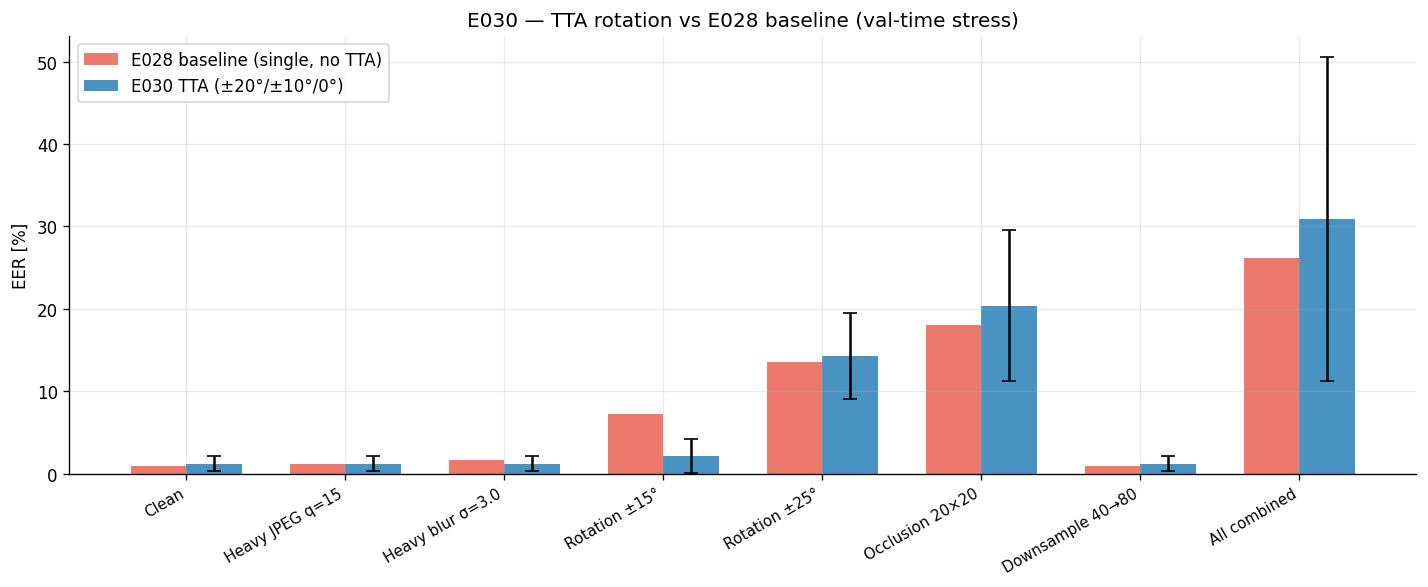

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
w = 0.35
bars_e028 = ax.bar(x - w/2, results['e028_mean'], w, label='E028 baseline (single, no TTA)',
                   color='#E74C3C', alpha=0.75)
bars_tta  = ax.bar(x + w/2, results['tta_mean'],  w, label='E030 TTA (±20°/±10°/0°)',
                   color='#2980B9', alpha=0.85,
                   yerr=results['tta_std'], capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(results['label'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('EER [%]')
ax.set_title('E030 — TTA rotation vs E028 baseline (val-time stress)')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

Fill in after running:
- Did clean EER stay ≤1.5%?
- Did rotation ±15° drop below 5%?
- Did occlusion/combined improve?
- Decision: adopt TTA in predict_image.py or keep flip-only TTA?